# `ActionSmoothnessRewardV0` — penalty demonstration

`ActionSmoothnessRewardV0` (a thin alias of `ActionSmoothnessReward`) penalises
high-frequency oscillation in actions via spectral analysis. For each action key
it keeps a ring buffer of the last `n_steps` actions, takes a real FFT, and
turns high-frequency spectral energy into a penalty in `[0, 1]` per key.

Two modes:
- **`weighted`** (default): every bin's energy is weighted by `w[k] = (k / (N/2))**freq_exponent`, so DC has weight 0 and Nyquist has weight 1 — a smooth, continuous penalty that grows as oscillation gets faster.
- **`highband`**: hard cutoff — only bins above `cutoff_fraction * (N/2)` contribute. Trends/ramps below the cutoff produce zero penalty.

This notebook uses a **single action key** (`a_hp`) and **4 action sequences of 16 steps**
(matching the default `n_steps = 16`, so the buffer is exactly full on the last step).
The reward returns `(weight * raw_reward, max_step)` with `raw_reward = -penalty`;
with `weight = 1` the **penalty** is just `-raw_reward`.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from adv_building_gym.components.rewards.action_smoothness_reward_v0 import ActionSmoothnessRewardV0

N_STEPS = 16
ACTION_KEY = "a_hp"


def penalties_per_step(sequence, mode, n_steps=N_STEPS, **kwargs):
    """Feed a 1-D action sequence step-by-step and return the per-step penalty.

    A fresh reward instance is created per call so the ring buffer starts empty
    (zero-padded) and fills up over the sequence. penalty = -raw_reward (weight=1).
    """
    reward = ActionSmoothnessRewardV0(weight=1.0, n_steps=n_steps, mode=mode, **kwargs)
    reward.on_reset({})
    out = []
    for a in sequence:
        raw_reward, _max_step = reward.get_reward({ACTION_KEY: np.array([a], dtype=np.float32)}, {})
        out.append(-float(raw_reward))
    return np.asarray(out)


def final_penalty(sequence, mode, **kwargs):
    """Penalty on the last step, i.e. once the 16-sample buffer is full."""
    return penalties_per_step(sequence, mode, **kwargs)[-1]

## The action scenarios

All scenarios have 16 samples and span the action range; they differ only in their
**frequency content**, which is exactly what the reward measures.

| Scenario | Description | Dominant frequency |
|---|---|---|
| 1. Constant | hold a fixed value | DC only (none) |
| 2. Slow ramp | linear drift `-1 → +1` | very low |
| 3. Ramp up-down (triangle) | rise `-1 → +1` then fall `+1 → -1` | low (one triangle cycle) |
| 4. Slow sine | one full cycle over the window | low |
| 5. Square wave | alternate `+1 / -1` every step | Nyquist (max) |

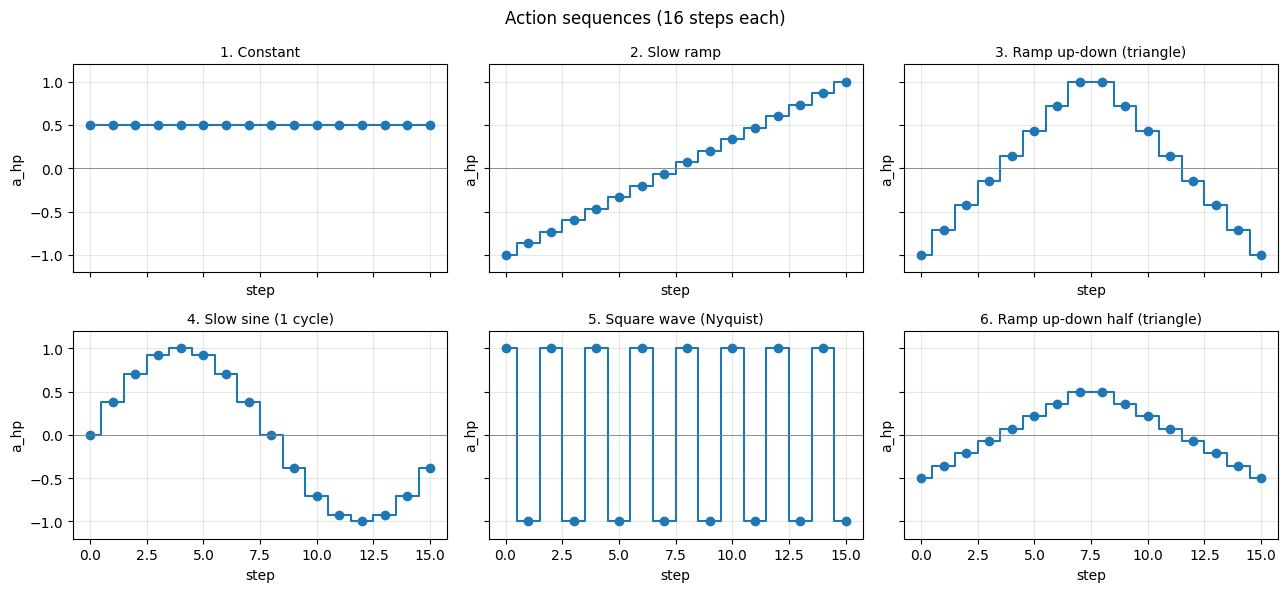

In [14]:
n = np.arange(N_STEPS)
half = N_STEPS // 2

scenarios = {
    "1. Constant": np.full(N_STEPS, 0.5),
    "2. Slow ramp": np.linspace(-1.0, 1.0, N_STEPS),
    "3. Ramp up-down (triangle)": np.concatenate(
        [np.linspace(-1.0, 1.0, half), np.linspace(1.0, -1.0, half)]
    ),
    "4. Slow sine (1 cycle)": np.sin(2 * np.pi * n / N_STEPS),
    "5. Square wave (Nyquist)": (-1.0) ** n,
    "6. Ramp up-down half (triangle)": np.concatenate(
        [np.linspace(-0.5, 0.5, half), np.linspace(0.5, -0.5, half)]
    ),
}

ncols = 3
nrows = int(np.ceil(len(scenarios) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 6), sharex=True, sharey=True)
axes = axes.ravel()
for ax, (label, seq) in zip(axes, scenarios.items()):
    ax.step(n, seq, where="mid", marker="o", color="tab:blue")
    ax.set_title(label, fontsize=10)
    ax.axhline(0.0, color="grey", lw=0.6)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel("step")
    ax.set_ylabel("a_hp")
    ax.grid(alpha=0.3)
for ax in axes[len(scenarios):]:
    ax.set_visible(False)
fig.suptitle("Action sequences (16 steps each)")
fig.tight_layout()
plt.show()

## Per-step penalty as the buffer fills

The ring buffer starts zero-padded, so early steps are dominated by the step
from 0 into the first real value. The penalty is meaningful once the buffer is
full (step 16 / index 15).

Linear y-axis. The **top row** shows the full `[0, 1]` range (the square wave
saturates near 1.0); the **bottom row** zooms in with the square wave removed,
so the linear axis auto-refines to the low-frequency scenarios (~0.01–0.05) and
their differences become visible.

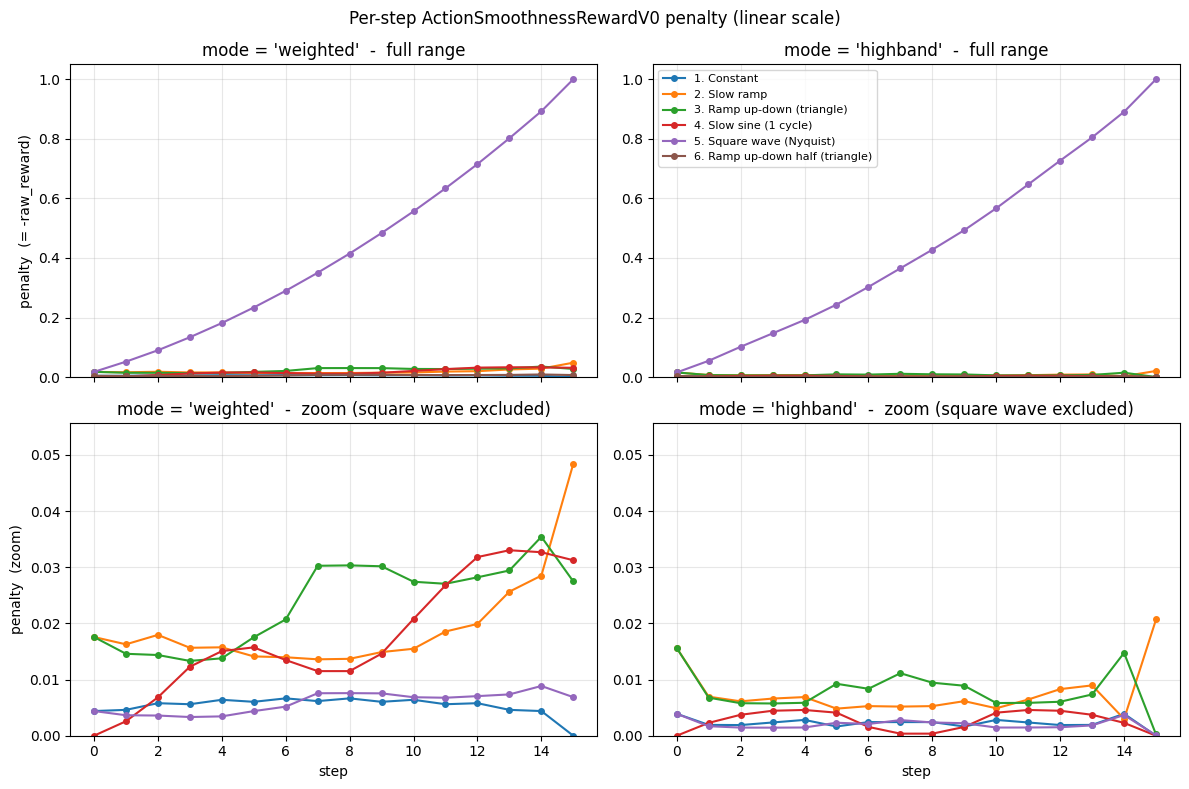

In [15]:
modes = ["weighted", "highband"]

# Precompute per-step penalties once per (mode, scenario).
pens = {
    mode: {label: penalties_per_step(seq, mode) for label, seq in scenarios.items()}
    for mode in modes
}

# Linear scale, but split into two rows so the tiny low-frequency penalties
# stay readable: top = full range (square wave saturates near 1.0), bottom =
# zoom that drops the square wave so the linear axis auto-refines to the
# small scenarios (~0.01-0.05).
zoom_keys = [k for k in scenarios if "Square" not in k]
zoom_max = max(pens[m][k].max() for m in modes for k in zoom_keys) * 1.15

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for j, mode in enumerate(modes):
    ax_full, ax_zoom = axes[0, j], axes[1, j]
    for label, seq in scenarios.items():
        ax_full.plot(n, pens[mode][label], marker="o", ms=4, label=label)
        if label in zoom_keys:
            ax_zoom.plot(n, pens[mode][label], marker="o", ms=4, label=label)
    ax_full.set_title(f"mode = '{mode}'  -  full range")
    ax_full.set_ylim(0, 1.05)
    ax_zoom.set_title(f"mode = '{mode}'  -  zoom (square wave excluded)")
    ax_zoom.set_ylim(0, zoom_max)
    ax_zoom.set_xlabel("step")
    ax_full.grid(alpha=0.3)
    ax_zoom.grid(alpha=0.3)
axes[0, 0].set_ylabel("penalty  (= -raw_reward)")
axes[1, 0].set_ylabel("penalty  (zoom)")
axes[0, 1].legend(loc="upper left", fontsize=8)
fig.suptitle("Per-step ActionSmoothnessRewardV0 penalty (linear scale)")
fig.tight_layout()
plt.show()

## Final penalty (full buffer) — `weighted` vs `highband`

Comparison of the steady-state penalty (last step) across scenarios and modes.

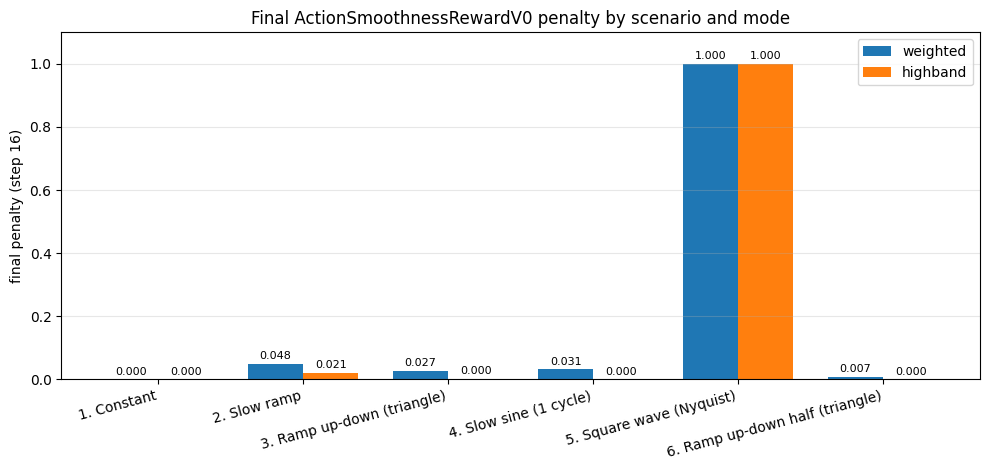

scenario                               weighted   highband
1. Constant                              0.0000     0.0000
2. Slow ramp                             0.0484     0.0207
3. Ramp up-down (triangle)               0.0275     0.0002
4. Slow sine (1 cycle)                   0.0312     0.0000
5. Square wave (Nyquist)                 1.0000     1.0000
6. Ramp up-down half (triangle)          0.0069     0.0001


In [16]:
labels = list(scenarios.keys())
weighted_vals = [final_penalty(scenarios[l], "weighted") for l in labels]
highband_vals = [final_penalty(scenarios[l], "highband") for l in labels]

x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 4.8))
b1 = ax.bar(x - width / 2, weighted_vals, width, label="weighted", color="tab:blue")
b2 = ax.bar(x + width / 2, highband_vals, width, label="highband", color="tab:orange")
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)
ax.set_xticks(x, labels, rotation=15, ha="right")
ax.set_ylabel("final penalty (step 16)")
ax.set_ylim(0, 1.1)
ax.set_title("Final ActionSmoothnessRewardV0 penalty by scenario and mode")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"{'scenario':36s} {'weighted':>10s} {'highband':>10s}")
for l, w, h in zip(labels, weighted_vals, highband_vals):
    print(f"{l:36s} {w:10.4f} {h:10.4f}")

## Takeaways

- **Constant** → ~0 penalty in both modes: after mean-subtraction there is no spectral energy at all.
- **Slow sine (one clean cycle)** → small penalty in `weighted` (low-frequency bins carry little weight) and exactly **0** in `highband` (all its energy sits in one low bin, below the cutoff).
- **Ramp up-down (triangle)** → also a low-frequency signal (one triangle cycle), so a small `weighted` penalty similar to the sine; its odd harmonics leak only a negligible amount above the `highband` cutoff, so `highband` stays ≈ 0.
- **Slow ramp** → small penalty in both modes. It is *not* periodic, so FFT spectral leakage spreads a little energy across all bins, including above the `highband` cutoff — hence a small but non-zero `highband` value rather than 0.
- **Square wave** → penalty `= 1.0` (the maximum) in both modes: a `±1` flip every step puts all energy at the Nyquist bin, which equals the analytical worst case `N**2` used for normalisation.

The key behavioural difference: `weighted` charges every frequency a little (smoothly), while `highband` is near-blind to clean low-frequency drift but still catches the broadband leakage of sharp transients (the non-periodic ramp).